# EGILEA: Hodei Sanz

# IMPORT-AK

In [41]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DATUAK KARGATU ETA GARBITU

In [42]:
def parse_experiment_name(folder_name: str) -> str:
    m = re.match(r"^emaitzak_sentiment_(.+)$", folder_name)
    return m.group(1) if m else folder_name


def load_all_metrics(root: str | Path = "emaitzak") -> pd.DataFrame:
    root = Path(root)
    pattern = root / "*" / "*" / "dev" / "metrics" / "*.csv"
    files = sorted(root.glob(str(pattern.relative_to(root))))

    rows = []

    for fp in files:
        experiment_folder = fp.parts[1]
        shot_type = fp.parts[2]
        split = fp.parts[3]
        model = fp.stem

        df = pd.read_csv(fp)

        df.insert(0, "shot_type", shot_type)
        df.insert(0, "split", split)
        df.insert(0, "model", model)
        df.insert(0, "experiment", parse_experiment_name(experiment_folder))

        rows.append(df)

    df = pd.concat(rows, ignore_index=True)

    df["Froga"] = pd.to_numeric(df["Froga"], errors="coerce")

    return df

In [43]:
# Datuak kargatu
df = load_all_metrics("emaitzak")

# Froga == 2 kendu, oso datu gutxi daudelako
df = df[df["Froga"] != 2].copy()
# GLOBAL lerroak kentzen ditugu, mediak erraz atera daitezkelako
df = df[df["Prompt"].astype(str).str.upper() != "GLOBAL"].copy()
df["Prompt"] = pd.to_numeric(df["Prompt"], errors="coerce")

# EMAITZEN ANALISIA

## DATUAK ONDO JARRI ATAL HONETARAKO

In [44]:
# Badaezpada berriro egin aldaketaren bat egiten bada
df_clean = df.copy()

# GLOBAL eta Froga 2 kentzen ditugu
df_clean = df_clean[df_clean["Froga"] != 2]
df_clean = df_clean[df_clean["Prompt"].astype(str).str.upper() != "GLOBAL"]

df_clean["Prompt"] = pd.to_numeric(df_clean["Prompt"], errors="coerce")

## FUNTZIO LAGUNGARRIAK

In [45]:
def plot_grouped_hbar(df_sum, title, x_label, col_macro, col_weighted,
                      label_macro="Macro", label_weighted="Weighted",
                      color_macro="steelblue", color_weighted="darkorange",
                      top_n=None):

    d = df_sum.copy()
    if top_n is not None:
        d = d.head(top_n)

    models = d["model"].astype(str).tolist()
    y = np.arange(len(models))
    h = 0.38

    macro_vals = d[col_macro].to_numpy()
    weighted_vals = d[col_weighted].to_numpy()

    max_val = max(macro_vals.max(), weighted_vals.max())

    plt.figure()

    plt.barh(y - h/2, macro_vals, height=h, label=label_macro, color=color_macro)
    plt.barh(y + h/2, weighted_vals, height=h, label=label_weighted, color=color_weighted)

    offset = max_val * 0.01

    for i, v in enumerate(macro_vals):
        plt.text(v + offset, y[i] - h/2, f"{v:.3f}", va="center")

    for i, v in enumerate(weighted_vals):
        plt.text(v + offset, y[i] + h/2, f"{v:.3f}", va="center")

    plt.xlim(0, max_val * 1.10)

    plt.yticks(y, models)
    plt.gca().invert_yaxis()

    plt.xlabel(x_label)
    plt.title(title)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [46]:
def best_models_from_summary(df_sum, macro_col, weighted_col, label, df_full):

    # ---- Best model by mean ----
    best_macro = df_sum.loc[df_sum[macro_col].idxmax(), ["model", macro_col]]
    best_weighted = df_sum.loc[df_sum[weighted_col].idxmax(), ["model", weighted_col]]

    print(f"=== BEST {label} (by mean) ===")
    print(f"Best (Macro):    {best_macro['model']}  -> {best_macro[macro_col]:.4f}")
    print(f"Best (Weighted): {best_weighted['model']}  -> {best_weighted[weighted_col]:.4f}")
    print()

    # ---- Absolute max/min over ALL DATA ----
    max_macro_idx = df_full["F1_macro"].idxmax()
    min_macro_idx = df_full["F1_macro"].idxmin()

    max_weighted_idx = df_full["F1_weighted"].idxmax()
    min_weighted_idx = df_full["F1_weighted"].idxmin()

    max_macro_row = df_full.loc[max_macro_idx]
    min_macro_row = df_full.loc[min_macro_idx]

    max_weighted_row = df_full.loc[max_weighted_idx]
    min_weighted_row = df_full.loc[min_weighted_idx]

    print("=== ABSOLUTE VALUES (ALL DATA) ===\n")

    print("Max F1_macro:")
    print(f"Value: {max_macro_row['F1_macro']:.4f}")
    print(f"Model: {max_macro_row['model']} | Froga: {max_macro_row['Froga']} | Prompt: {max_macro_row['Prompt']}")
    print()

    print("Min F1_macro:")
    print(f"Value: {min_macro_row['F1_macro']:.4f}")
    print(f"Model: {min_macro_row['model']} | Froga: {min_macro_row['Froga']} | Prompt: {min_macro_row['Prompt']}")
    print()

    print("Max F1_weighted:")
    print(f"Value: {max_weighted_row['F1_weighted']:.4f}")
    print(f"Model: {max_weighted_row['model']} | Froga: {max_weighted_row['Froga']} | Prompt: {max_weighted_row['Prompt']}")
    print()

    print("Min F1_weighted:")
    print(f"Value: {min_weighted_row['F1_weighted']:.4f}")
    print(f"Model: {min_weighted_row['model']} | Froga: {min_weighted_row['Froga']} | Prompt: {min_weighted_row['Prompt']}")
    print()

In [47]:
def build_pivot(df_in, value_col):
    pivot = (
        df_in
        .groupby(["model", "shot_type"], as_index=False)[value_col]
        .mean()
        .pivot(index="model", columns="shot_type", values=value_col)
    )

    preferred_cols = ["zero-shot", "few-shot-1", "few-shot-2"]
    cols = [c for c in preferred_cols if c in pivot.columns] + \
           [c for c in pivot.columns if c not in preferred_cols]
    pivot = pivot[cols]

    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    return pivot

def build_pivot_model_froga(df_in, value_col):
    pivot = (
        df_in
        .groupby(["model", "Froga"], as_index=False)[value_col]
        .mean()
        .pivot(index="model", columns="Froga", values=value_col)
    )

    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    return pivot

## PRECISION

In [48]:
precision_macro_summary = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        mean_precision_macro=("Precision_macro", "mean"),
        std_precision_macro=("Precision_macro", "std")
    )
    .sort_values("mean_precision_macro", ascending=False)
    .reset_index(drop=True)
)

precision_macro_summary

,model,mean_precision_macro,std_precision_macro
0,salamandra-7B,0.627633,0.073854
1,latxa3.1-8B,0.579536,0.169296
2,llama3.1-70B,0.548940,0.137990
3,llama3.1-8B,0.545454,0.152458
4,latxa3.1-70B,0.306192,0.151191


In [49]:
precision_weighted_summary = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        mean_precision_weighted=("Precision_weighted", "mean"),
        std_precision_weighted=("Precision_weighted", "std")
    )
    .sort_values("mean_precision_weighted", ascending=False)
    .reset_index(drop=True)
)

precision_weighted_summary

,model,mean_precision_weighted,std_precision_weighted
0,salamandra-7B,0.633075,0.066176
1,latxa3.1-8B,0.583105,0.197553
2,llama3.1-70B,0.559928,0.129817
3,llama3.1-8B,0.536943,0.138498
4,latxa3.1-70B,0.356090,0.133511


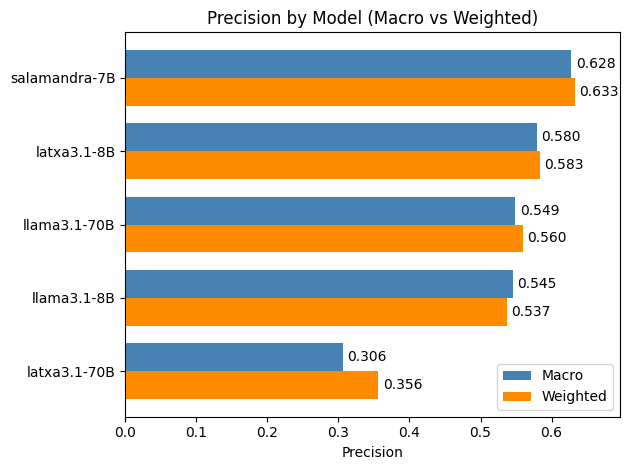

In [50]:
precision_sum = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        precision_macro=("Precision_macro", "mean"),
        precision_weighted=("Precision_weighted", "mean"),
    )
    .sort_values("precision_macro", ascending=False)
    .reset_index(drop=True)
)

plot_grouped_hbar(
    precision_sum,
    title="Precision by Model (Macro vs Weighted)",
    x_label="Precision",
    col_macro="precision_macro",
    col_weighted="precision_weighted",
    color_macro="steelblue",
    color_weighted="darkorange",
    top_n=None 
)

In [51]:
best_models_from_summary(precision_sum, "precision_macro", "precision_weighted", "PRECISION", df_clean)

=== BEST PRECISION (by mean) ===
Best (Macro):    salamandra-7B  -> 0.6276
Best (Weighted): salamandra-7B  -> 0.6331

=== ABSOLUTE VALUES (ALL DATA) ===

Max F1_macro:
Value: 0.6990
Model: latxa3.1-8B | Froga: 1 | Prompt: 1

Min F1_macro:
Value: 0.1148
Model: latxa3.1-70B | Froga: 1 | Prompt: 3

Max F1_weighted:
Value: 0.7172
Model: latxa3.1-8B | Froga: 4 | Prompt: 3

Min F1_weighted:
Value: 0.0724
Model: latxa3.1-70B | Froga: 1 | Prompt: 3



## RECALL

In [52]:
recall_macro_summary = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        mean_recall_macro=("Recall_macro", "mean"),
        std_recall_macro=("Recall_macro", "std")
    )
    .sort_values("mean_recall_macro", ascending=False)
    .reset_index(drop=True)
)

recall_macro_summary

,model,mean_recall_macro,std_recall_macro
0,salamandra-7B,0.578157,0.069765
1,latxa3.1-8B,0.519471,0.107497
2,llama3.1-8B,0.448358,0.085661
3,llama3.1-70B,0.445006,0.054055
4,latxa3.1-70B,0.346599,0.040660


In [53]:
recall_weighted_summary = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        mean_recall_weighted=("Recall_weighted", "mean"),
        std_recall_weighted=("Recall_weighted", "std")
    )
    .sort_values("mean_recall_weighted", ascending=False)
    .reset_index(drop=True)
)

recall_weighted_summary

,model,mean_recall_weighted,std_recall_weighted
0,salamandra-7B,0.614489,0.070309
1,llama3.1-8B,0.530066,0.067051
2,llama3.1-70B,0.525945,0.043608
3,latxa3.1-8B,0.514721,0.125809
4,latxa3.1-70B,0.448494,0.083405


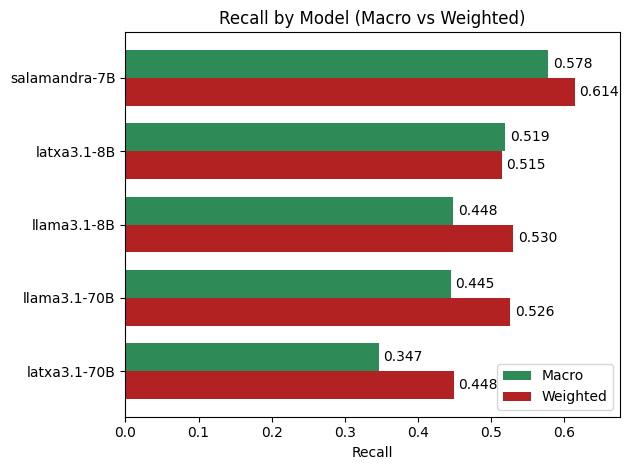

In [54]:
recall_sum = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        recall_macro=("Recall_macro", "mean"),
        recall_weighted=("Recall_weighted", "mean"),
    )
    .sort_values("recall_macro", ascending=False)
    .reset_index(drop=True)
)

plot_grouped_hbar(
    recall_sum,
    title="Recall by Model (Macro vs Weighted)",
    x_label="Recall",
    col_macro="recall_macro",
    col_weighted="recall_weighted",
    color_macro="seagreen",
    color_weighted="firebrick",
    top_n=None
)

In [55]:
best_models_from_summary(recall_sum, "recall_macro", "recall_weighted", "RECALL", df_clean)

=== BEST RECALL (by mean) ===
Best (Macro):    salamandra-7B  -> 0.5782
Best (Weighted): salamandra-7B  -> 0.6145

=== ABSOLUTE VALUES (ALL DATA) ===

Max F1_macro:
Value: 0.6990
Model: latxa3.1-8B | Froga: 1 | Prompt: 1

Min F1_macro:
Value: 0.1148
Model: latxa3.1-70B | Froga: 1 | Prompt: 3

Max F1_weighted:
Value: 0.7172
Model: latxa3.1-8B | Froga: 4 | Prompt: 3

Min F1_weighted:
Value: 0.0724
Model: latxa3.1-70B | Froga: 1 | Prompt: 3



## F1-SCORE

### RESUMEN GENERALA

In [56]:
f1_summary = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        mean_f1_macro=("F1_macro", "mean"),
        std_f1_macro=("F1_macro", "std"),
        mean_f1_weighted=("F1_weighted", "mean"),
        std_f1_weighted=("F1_weighted", "std")
    )
    .sort_values("mean_f1_macro", ascending=False)
    .reset_index(drop=True)
)

f1_summary

,model,mean_f1_macro,std_f1_macro,mean_f1_weighted,std_f1_weighted
0,salamandra-7B,0.576417,0.074876,0.600809,0.077658
1,latxa3.1-8B,0.459001,0.155065,0.453072,0.175853
2,llama3.1-8B,0.404634,0.110365,0.451318,0.095243
3,llama3.1-70B,0.401871,0.073570,0.445900,0.066495
4,latxa3.1-70B,0.252052,0.069144,0.324697,0.080476


In [57]:
f1_sum = (
    df_clean
    .groupby("model", as_index=False)
    .agg(
        f1_macro_mean=("F1_macro", "mean"),
        f1_macro_std=("F1_macro", "std"),
        f1_weighted_mean=("F1_weighted", "mean"),
        f1_weighted_std=("F1_weighted", "std"),
        n=("F1_macro", "count")
    )
)

best_models_from_summary(
    df_sum=f1_sum,
    macro_col="f1_macro_mean",
    weighted_col="f1_weighted_mean",
    label="F1",
    df_full=df_clean
)

=== BEST F1 (by mean) ===
Best (Macro):    salamandra-7B  -> 0.5764
Best (Weighted): salamandra-7B  -> 0.6008

=== ABSOLUTE VALUES (ALL DATA) ===

Max F1_macro:
Value: 0.6990
Model: latxa3.1-8B | Froga: 1 | Prompt: 1

Min F1_macro:
Value: 0.1148
Model: latxa3.1-70B | Froga: 1 | Prompt: 3

Max F1_weighted:
Value: 0.7172
Model: latxa3.1-8B | Froga: 4 | Prompt: 3

Min F1_weighted:
Value: 0.0724
Model: latxa3.1-70B | Froga: 1 | Prompt: 3



### Macro/Weighted froga bakoitzerako modelo bakoitzarekin

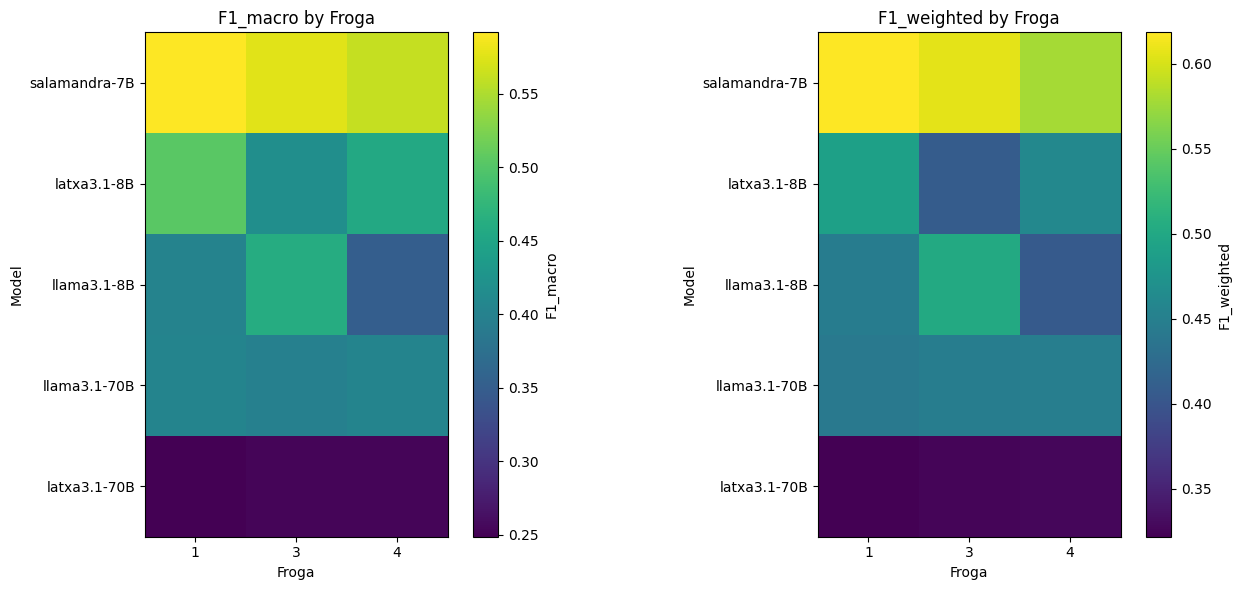

In [58]:
pivot_macro = build_pivot_model_froga(df_clean, "F1_macro")
pivot_weighted = build_pivot_model_froga(df_clean, "F1_weighted")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Macro ----
im_macro = axes[0].imshow(pivot_macro.values)
axes[0].set_title("F1_macro by Froga")
axes[0].set_xlabel("Froga")
axes[0].set_ylabel("Model")
axes[0].set_xticks(range(len(pivot_macro.columns)))
axes[0].set_xticklabels(pivot_macro.columns)
axes[0].set_yticks(range(len(pivot_macro.index)))
axes[0].set_yticklabels(pivot_macro.index)

cbar_macro = fig.colorbar(im_macro, ax=axes[0], fraction=0.046, pad=0.04)
cbar_macro.set_label("F1_macro")

# ---- Weighted ----
im_weighted = axes[1].imshow(pivot_weighted.values)
axes[1].set_title("F1_weighted by Froga")
axes[1].set_xlabel("Froga")
axes[1].set_ylabel("Model")
axes[1].set_xticks(range(len(pivot_weighted.columns)))
axes[1].set_xticklabels(pivot_weighted.columns)
axes[1].set_yticks(range(len(pivot_weighted.index)))
axes[1].set_yticklabels(pivot_weighted.index)

cbar_weighted = fig.colorbar(im_weighted, ax=axes[1], fraction=0.046, pad=0.04)
cbar_weighted.set_label("F1_weighted")

plt.tight_layout()
plt.show()

In [59]:
pivot_macro

Froga,1,3,4
model,,,
salamandra-7B,0.591734,0.575751,0.561766
latxa3.1-8B,0.503814,0.417631,0.455557
llama3.1-8B,0.401864,0.461111,0.350927
llama3.1-70B,0.403598,0.398808,0.403208
latxa3.1-70B,0.248796,0.253464,0.253896


In [60]:
pivot_weighted

Froga,1,3,4
model,,,
salamandra-7B,0.618364,0.605862,0.578202
latxa3.1-8B,0.490467,0.408386,0.460363
llama3.1-8B,0.446028,0.501807,0.406118
llama3.1-70B,0.441386,0.447987,0.448327
latxa3.1-70B,0.321695,0.325497,0.326897


### Macro/Weighted -shot bakoitzerako modelo bakoitzarekin

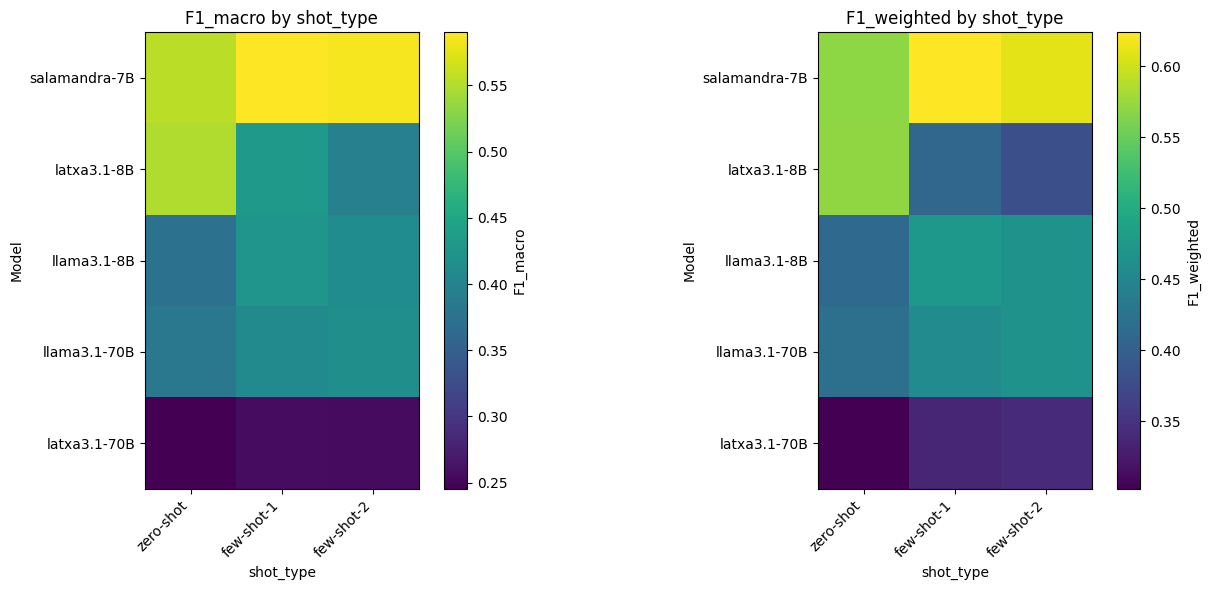

In [ ]:
def build_pivot_model_shot(df_in, value_col):
    # model × shot_type pivot taula sortzen dugu
    pivot = (
        df_in
        .groupby(["model", "shot_type"], as_index=False)[value_col]
        .mean()
        .pivot(index="model", columns="shot_type", values=value_col)
    )

    # zutabe orden logikoa ezartzen dugu
    preferred_cols = ["zero-shot", "few-shot-1", "few-shot-2"]
    cols = [c for c in preferred_cols if c in pivot.columns] + \
           [c for c in pivot.columns if c not in preferred_cols]
    pivot = pivot[cols]

    # errenkadak batez bestekoaren arabera ordenatzen ditugu
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    return pivot


pivot_macro = build_pivot_model_shot(df_clean, "F1_macro")
pivot_weighted = build_pivot_model_shot(df_clean, "F1_weighted")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Macro ----
im_macro = axes[0].imshow(pivot_macro.values)
axes[0].set_title("F1_macro by shot_type")
axes[0].set_xlabel("shot_type")
axes[0].set_ylabel("Model")
axes[0].set_xticks(range(len(pivot_macro.columns)))
axes[0].set_xticklabels(pivot_macro.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(pivot_macro.index)))
axes[0].set_yticklabels(pivot_macro.index)

cbar_macro = fig.colorbar(im_macro, ax=axes[0], fraction=0.046, pad=0.04)
cbar_macro.set_label("F1_macro")

# ---- Weighted ----
im_weighted = axes[1].imshow(pivot_weighted.values)
axes[1].set_title("F1_weighted by shot_type")
axes[1].set_xlabel("shot_type")
axes[1].set_ylabel("Model")
axes[1].set_xticks(range(len(pivot_weighted.columns)))
axes[1].set_xticklabels(pivot_weighted.columns, rotation=45, ha="right")
axes[1].set_yticks(range(len(pivot_weighted.index)))
axes[1].set_yticklabels(pivot_weighted.index)

cbar_weighted = fig.colorbar(im_weighted, ax=axes[1], fraction=0.046, pad=0.04)
cbar_weighted.set_label("F1_weighted")

plt.tight_layout()
plt.show()

In [62]:
pivot_macro

shot_type,zero-shot,few-shot-1,few-shot-2
model,,,
salamandra-7B,0.554615,0.590167,0.585476
latxa3.1-8B,0.548921,0.431924,0.396158
llama3.1-8B,0.375615,0.425366,0.412921
llama3.1-70B,0.383644,0.410104,0.417074
latxa3.1-70B,0.245270,0.257264,0.255559


In [63]:
pivot_weighted

shot_type,zero-shot,few-shot-1,few-shot-2
model,,,
salamandra-7B,0.569374,0.623751,0.610366
latxa3.1-8B,0.570827,0.408064,0.380325
llama3.1-8B,0.412240,0.474107,0.467606
llama3.1-70B,0.420505,0.457546,0.466905
latxa3.1-70B,0.302409,0.337130,0.340918


# DENBORAREN ANALISIA

## DATUAK ONDO JARRI ATAL HONETARAKO

In [64]:
# Badaezpada berriro sortu erabiliko den dataframe-a
df_clean = df.copy()
df_clean = df_clean[df_clean["Froga"] != 2].copy()
df_clean = df_clean[df_clean["Prompt"].astype(str).str.upper() != "GLOBAL"].copy()

## FUNTZIO LAGUNGARRIAK

In [65]:
def pareto_mask(df_in: pd.DataFrame, time_col: str, quality_col: str) -> np.ndarray:
    """
    Returns a boolean mask (True = on Pareto frontier).
    Minimization on time_col, maximization on quality_col.
    """
    # Pareto frontier kalkulatzen dugu (denbora txikiagoa hobea; kalitatea handiagoa hobea)
    x = df_in[time_col].to_numpy()
    y = df_in[quality_col].to_numpy()
    n = len(df_in)

    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        # j dominates i if: xj <= xi and yj >= yi and at least one strict
        dominates_i = (x <= x[i]) & (y >= y[i]) & ((x < x[i]) | (y > y[i]))
        dominates_i[i] = False
        if np.any(dominates_i):
            is_pareto[i] = False

    return is_pareto


def make_group_summary(df_in: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """
    Aggregates to (group_col, model) with mean quality/time.
    """
    # taldearen arabera (Froga/Prompt/shot_type) eta modelaren arabera batezbestekoak kalkulatzen ditugu
    out = (
        df_in
        .groupby([group_col, "model"], as_index=False)
        .agg(
            mean_time=("Avg_exec_time", "mean"),
            mean_macro=("F1_macro", "mean"),
            mean_weighted=("F1_weighted", "mean"),
            n_runs=("Avg_exec_time", "count")
        )
    )
    return out


def plot_all_groups_with_pareto(summary_df: pd.DataFrame, group_col: str, quality_col: str, title: str, label_pareto: bool = True):
    """
    One scatter containing all points (all groups), with Pareto highlighted.
    Pareto is computed globally across all points in this plot.
    """
    # plot bakarrean puntu guztiak sartzen ditugu eta Pareto puntuak nabarmendu
    dfp = summary_df.dropna(subset=["mean_time", quality_col]).copy()

    mask = pareto_mask(dfp, time_col="mean_time", quality_col=quality_col)
    pareto_pts = dfp[mask]
    other_pts = dfp[~mask]

    plt.figure()
    plt.scatter(other_pts["mean_time"], other_pts[quality_col])   # default style
    plt.scatter(pareto_pts["mean_time"], pareto_pts[quality_col]) # highlighted by being second series

    if label_pareto:
        # Pareto puntuak etiketatzen ditugu (model + group)
        for _, r in pareto_pts.iterrows():
            plt.text(
                r["mean_time"],
                r[quality_col],
                f'{r["model"]} | {group_col}={r[group_col]}'
            )

    plt.xlabel("Mean execution time (s)")
    plt.ylabel(quality_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return dfp, pareto_pts


def pareto_frontier_2d_all_points(df_in: pd.DataFrame, time_col: str, quality_col: str) -> pd.DataFrame:
    """
    Returns Pareto-optimal points for 2D:
    - minimize time_col
    - maximize quality_col
    Uses an O(n log n) method:
      sort by time ascending, keep points that improve the best quality seen so far.
    """
    # NaN-ak kentzen ditugu (bestela Pareto kalkulua hondatzen da)
    d = df_in.dropna(subset=[time_col, quality_col]).copy()

    # denboraren arabera ordenatzen dugu (txikiena lehenengo)
    d = d.sort_values([time_col, quality_col], ascending=[True, False]).reset_index(drop=True)

    # Pareto puntuak aukeratzen ditugu; kalitatea maximo berria egiten dutenak
    best_q = -np.inf
    keep = np.zeros(len(d), dtype=bool)

    for i, q in enumerate(d[quality_col].to_numpy()):
        if q > best_q:
            keep[i] = True
            best_q = q

    pareto = d[keep].copy()
    return pareto


def plot_all_points_with_pareto(df_in: pd.DataFrame, pareto_df: pd.DataFrame, time_col: str, quality_col: str, title: str):
    """
    Scatter of all points + Pareto highlighted.
    """
    # puntu guztiak + Pareto puntuak nabarmenduta
    plt.figure()
    plt.scatter(df_in[time_col], df_in[quality_col])
    plt.scatter(pareto_df[time_col], pareto_df[quality_col])

    plt.xlabel(time_col)
    plt.ylabel(quality_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()


## BEGIRADA AZKAR BAT

In [66]:
# Modeloen azkartasuna
ranking_time_general = (
    df
    .groupby("model", as_index=False)
    .agg(
        mean_time=("Avg_exec_time", "mean"),
        std_time=("Avg_exec_time", "std"),
        n_runs=("Avg_exec_time", "count")
    )
    .sort_values("mean_time", ascending=True)
    .reset_index(drop=True)
)
                                                                                                                                                       
ranking_time_general

,model,mean_time,std_time,n_runs
0,latxa3.1-8B,0.164972,0.119241,216
1,salamandra-7B,0.202324,0.257851,234
2,llama3.1-8B,0.255522,0.241069,216
3,llama3.1-70B,1.104716,1.057339,207
4,latxa3.1-70B,1.434859,0.822573,207


## PARETOAK

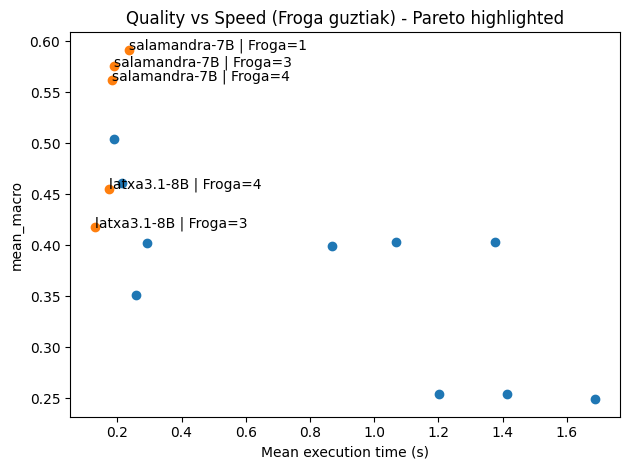

,Froga,model,mean_time,mean_macro,mean_weighted,n_runs
6,3,latxa3.1-8B,0.130613,0.417631,0.408386,72
11,4,latxa3.1-8B,0.174213,0.455557,0.460363,72
14,4,salamandra-7B,0.182224,0.561766,0.578202,78
9,3,salamandra-7B,0.188763,0.575751,0.605862,78
4,1,salamandra-7B,0.235986,0.591734,0.618364,78


In [67]:
# ---- PARETO: FROGA GROUPED, MACRO ----
froga_summary = make_group_summary(df, "Froga")

_fo_all, froga_pareto = plot_all_groups_with_pareto(
    summary_df=froga_summary,
    group_col="Froga",
    quality_col="mean_macro",  # cambia a "mean_weighted" si quieres
    title="Quality vs Speed (Froga guztiak) - Pareto highlighted",
    label_pareto=True
)

froga_pareto.sort_values(["mean_time"]).head(20)

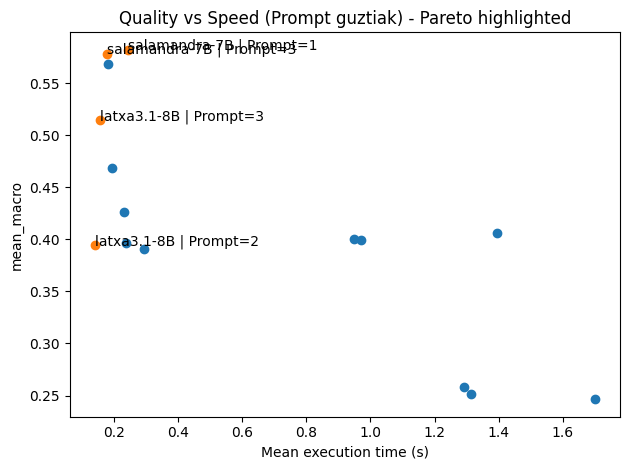

,Prompt,model,mean_time,mean_macro,mean_weighted,n_runs
6,2,latxa3.1-8B,0.141730,0.394186,0.380174,72
11,3,latxa3.1-8B,0.157650,0.514616,0.503971,72
14,3,salamandra-7B,0.178946,0.578623,0.608185,78
4,1,salamandra-7B,0.245615,0.582280,0.607667,78


In [68]:
# ---- PARETO: PROMPT GROUPED, MACRO ----
prompt_summary = make_group_summary(df, "Prompt")

_pr_all, prompt_pareto = plot_all_groups_with_pareto(
    summary_df=prompt_summary,
    group_col="Prompt",
    quality_col="mean_macro",  # o "mean_weighted"
    title="Quality vs Speed (Prompt guztiak) - Pareto highlighted",
    label_pareto=True
)

prompt_pareto.sort_values(["mean_time"]).head(20)

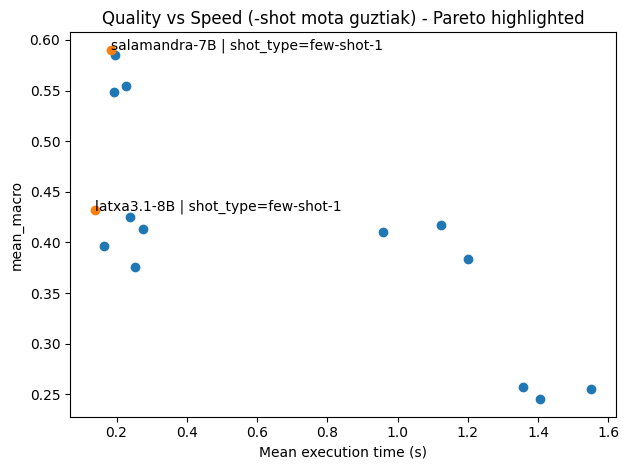

,shot_type,model,mean_time,mean_macro,mean_weighted,n_runs
1,few-shot-1,latxa3.1-8B,0.138186,0.431924,0.408064,72
4,few-shot-1,salamandra-7B,0.183176,0.590167,0.623751,81


In [69]:
# ---- PARETO: -SHOT GROUPED, MACRO ----
shot_summary = make_group_summary(df, "shot_type")

_sh_all, shot_pareto = plot_all_groups_with_pareto(
    summary_df=shot_summary,
    group_col="shot_type",
    quality_col="mean_macro",  # o "mean_weighted"
    title="Quality vs Speed (-shot mota guztiak) - Pareto highlighted",
    label_pareto=True
)

shot_pareto.sort_values(["mean_time"]).head(20)

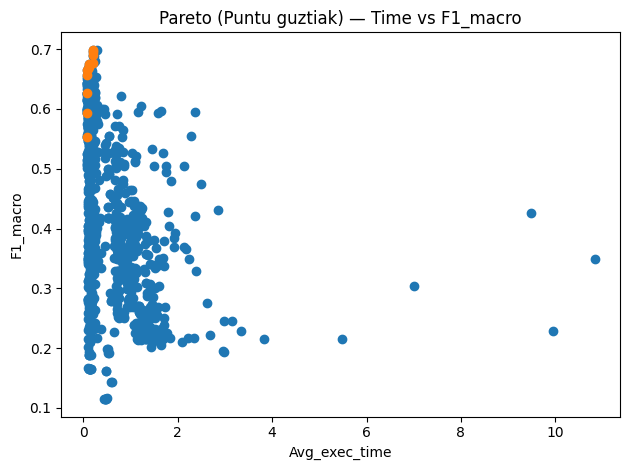

,experiment,model,split,shot_type,Froga,Prompt,F1_macro,Avg_exec_time
0,v2_SysPromptMotza,salamandra-7B,dev,zero-shot,4,2,0.553658,0.072368
1,v2_SysPromptMotza,salamandra-7B,dev,zero-shot,4,1,0.593835,0.073252
2,v2_SysPromptMotza,salamandra-7B,dev,zero-shot,4,3,0.627090,0.073265
4,v2_SysPromptMotza,salamandra-7B,dev,zero-shot,1,3,0.656209,0.073414
10,v1_SysPromptMotza,salamandra-7B,dev,zero-shot,1,3,0.665773,0.076417
118,v2_SysPromptLuzea,salamandra-7B,dev,few-shot-2,1,1,0.667584,0.103908
184,v1_SysPromptBerria1,salamandra-7B,dev,few-shot-1,1,3,0.670021,0.116152
239,v2_SysPromptLuzea,salamandra-7B,dev,few-shot-2,4,2,0.672024,0.121283
256,v2_SysPromptLuzea,salamandra-7B,dev,few-shot-2,4,3,0.675809,0.123467
514,v2_SysPromptBerria1,latxa3.1-8B,dev,few-shot-1,1,1,0.677399,0.196898


In [70]:
# ---- PARETO: ALL POINTS, MACRO ----
pareto_all_macro = pareto_frontier_2d_all_points(
    df_clean,
    time_col="Avg_exec_time",
    quality_col="F1_macro"
)

plot_all_points_with_pareto(
    df_in=df_clean.dropna(subset=["Avg_exec_time", "F1_macro"]),
    pareto_df=pareto_all_macro,
    time_col="Avg_exec_time",
    quality_col="F1_macro",
    title="Pareto (Puntu guztiak) — Time vs F1_macro"
)

# Pareto puntuen taula (informazio erabilgarria)
pareto_all_macro[["experiment","model","split","shot_type","Froga","Prompt","F1_macro","Avg_exec_time"]].sort_values("Avg_exec_time").head(30)

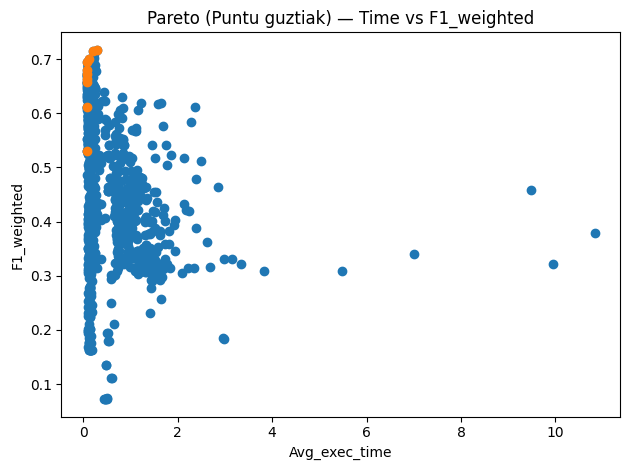

,experiment,model,split,shot_type,Froga,Prompt,F1_weighted,Avg_exec_time
0,v2_SysPromptMotza,salamandra-7B,dev,zero-shot,4,2,0.529790,0.072368
1,v2_SysPromptMotza,salamandra-7B,dev,zero-shot,4,1,0.611478,0.073252
2,v2_SysPromptMotza,salamandra-7B,dev,zero-shot,4,3,0.656938,0.073265
4,v2_SysPromptMotza,salamandra-7B,dev,zero-shot,1,3,0.663144,0.073414
10,v1_SysPromptMotza,salamandra-7B,dev,zero-shot,1,3,0.672417,0.076417
14,v2_SysPromptMotza,salamandra-7B,dev,few-shot-1,1,3,0.679981,0.077272
18,v1_SysPromptMotza,salamandra-7B,dev,few-shot-1,1,3,0.693978,0.080568
289,v1_SysPromptBerria2,salamandra-7B,dev,few-shot-1,1,3,0.699439,0.126774
518,v2_SysPromptBerria2,latxa3.1-8B,dev,few-shot-1,4,3,0.715835,0.198039
583,v1_SysPromptBerria1,latxa3.1-8B,dev,few-shot-2,4,3,0.717226,0.281686


In [71]:
# ---- PARETO: ALL POINTS, WEIGHTED ----
pareto_all_weighted = pareto_frontier_2d_all_points(
    df_clean,
    time_col="Avg_exec_time",
    quality_col="F1_weighted"
)

plot_all_points_with_pareto(
    df_in=df_clean.dropna(subset=["Avg_exec_time", "F1_weighted"]),
    pareto_df=pareto_all_weighted,
    time_col="Avg_exec_time",
    quality_col="F1_weighted",
    title="Pareto (Puntu guztiak) — Time vs F1_weighted"
)

pareto_all_weighted[["experiment","model","split","shot_type","Froga","Prompt","F1_weighted","Avg_exec_time"]].sort_values("Avg_exec_time").head(30)

# KONBINAZIO HOBERENA AURKITZEA

Erabiliko den dataset-a sortu

In [72]:
df_opt = df.copy()

# GLOBAL eta Froga 2 kentzen ditugu
df_opt = df_opt[df_opt["Froga"] != 2]
df_opt = df_opt[df_opt["Prompt"].astype(str).str.upper() != "GLOBAL"]

df_opt["Prompt"] = pd.to_numeric(df_opt["Prompt"], errors="coerce")

## ESPERIMENTU HOBERENA

In [ ]:
experiment_macro = (
    df_opt
    .groupby("experiment", as_index=False)
    .agg(
        mean_f1_macro=("F1_macro", "mean"),
        std_f1_macro=("F1_macro", "std"),
        mean_time=("Avg_exec_time", "mean")
    )
    .sort_values("mean_f1_macro", ascending=False)
    .reset_index(drop=True)
)

experiment_macro

,experiment,mean_f1_macro,std_f1_macro,mean_time
0,v1_SysPromptBerria1,0.479251,0.142360,0.551305
1,v2_SysPromptBerria2,0.438683,0.153629,0.629165
2,v2_SysPromptBerria1,0.433661,0.148204,0.592088
3,v1_SysPromptBerria2,0.426692,0.166813,0.991932
4,v1_SysPromptLuzea,0.419737,0.138066,0.602955
5,v2_SysPromptLuzea,0.416498,0.149346,0.621949
6,v2_SysPromptMotza,0.414731,0.148388,0.416251
7,v1_SysPromptMotza,0.411210,0.162857,0.467892
8,v1_preSysPrompt,0.383866,0.105055,0.918394


In [ ]:
experiment_weighted = (
    df_opt
    .groupby("experiment", as_index=False)
    .agg(
        mean_f1_weighted=("F1_weighted", "mean"),
        std_f1_weighted=("F1_weighted", "std"),
        mean_time=("Avg_exec_time", "mean")
    )
    .sort_values("mean_f1_weighted", ascending=False)
    .reset_index(drop=True)
)

experiment_weighted

,experiment,mean_f1_weighted,std_f1_weighted,mean_time
0,v1_SysPromptBerria1,0.502289,0.139986,0.551305
1,v2_SysPromptBerria2,0.476326,0.131651,0.629165
2,v1_SysPromptBerria2,0.473772,0.143266,0.991932
3,v2_SysPromptBerria1,0.468628,0.132739,0.592088
4,v1_SysPromptLuzea,0.465289,0.128209,0.602955
5,v2_SysPromptLuzea,0.462375,0.131128,0.621949
6,v1_SysPromptMotza,0.444683,0.166567,0.467892
7,v2_SysPromptMotza,0.443332,0.151124,0.416251
8,v1_preSysPrompt,0.414691,0.107838,0.918394


In [98]:
best_macro_exp = df_opt.loc[df_opt["F1_macro"].idxmax(), ["experiment", "F1_macro"]]
best_weighted_exp = df_opt.loc[df_opt["F1_weighted"].idxmax(), ["experiment", "F1_weighted"]]

print("Best absolute F1_macro:", best_macro_exp.to_dict())
print("Best absolute F1_weighted:", best_weighted_exp.to_dict())

Best absolute F1_macro: {'experiment': 'v2_SysPromptBerria2', 'F1_macro': 0.6989626044677467}
Best absolute F1_weighted: {'experiment': 'v1_SysPromptBerria1', 'F1_weighted': 0.7172264984296234}


## ATRIBUTUZKA ONENA

F1_macro maximo absolutua

In [73]:
best_macro_row = df_opt.loc[df_opt["F1_macro"].idxmax()]

best_macro_row[[
    "experiment", "model", "shot_type",
    "Froga", "Prompt",
    "F1_macro", "Avg_exec_time"
]]

experiment       v2_SysPromptBerria2
model                    latxa3.1-8B
shot_type                 few-shot-2
Froga                              1
Prompt                             1
F1_macro                    0.698963
Avg_exec_time               0.215218
Name: 1244, dtype: object

F1_weighted maximo absolutua

In [74]:
best_weighted_row = df_opt.loc[df_opt["F1_weighted"].idxmax()]

best_weighted_row[[
    "experiment", "model", "shot_type",
    "Froga", "Prompt",
    "F1_weighted", "Avg_exec_time"
]]

experiment       v1_SysPromptBerria1
model                    latxa3.1-8B
shot_type                 few-shot-2
Froga                              4
Prompt                             3
F1_weighted                 0.717226
Avg_exec_time               0.281686
Name: 62, dtype: object

Azkarrena

In [75]:
fastest_row = df_opt.loc[df_opt["Avg_exec_time"].idxmin()]

fastest_row[[
    "experiment", "model", "shot_type",
    "Froga", "Prompt",
    "F1_macro", "F1_weighted", "Avg_exec_time"
]]

experiment       v2_SysPromptMotza
model                salamandra-7B
shot_type                zero-shot
Froga                            4
Prompt                           2
F1_macro                  0.553658
F1_weighted                0.52979
Avg_exec_time             0.072368
Name: 1865, dtype: object

Hoberena kalitate/denbora-ko:

score = F1/denbora

Macro

In [76]:
df_opt["efficiency_macro"] = df_opt["F1_macro"] / df_opt["Avg_exec_time"]

best_eff_macro = df_opt.loc[df_opt["efficiency_macro"].idxmax()]

best_eff_macro[[
    "experiment", "model", "shot_type",
    "Froga", "Prompt",
    "F1_macro", "Avg_exec_time", "efficiency_macro"
]]

experiment          v2_SysPromptMotza
model                   salamandra-7B
shot_type                   zero-shot
Froga                               1
Prompt                              3
F1_macro                     0.656209
Avg_exec_time                0.073414
efficiency_macro               8.9385
Name: 1854, dtype: object

Weighted

In [77]:
df_opt["efficiency_weighted"] = df_opt["F1_weighted"] / df_opt["Avg_exec_time"]

best_eff_weighted = df_opt.loc[df_opt["efficiency_weighted"].idxmax()]

best_eff_weighted[[
    "experiment", "model", "shot_type",
    "Froga", "Prompt",
    "F1_weighted", "Avg_exec_time", "efficiency_weighted"
]]

experiment             v2_SysPromptMotza
model                      salamandra-7B
shot_type                      zero-shot
Froga                                  1
Prompt                                 3
F1_weighted                     0.663144
Avg_exec_time                   0.073414
efficiency_weighted             9.032962
Name: 1854, dtype: object

Top 10 F1_macro

In [78]:
top10_macro = (
    df_opt
    .sort_values("F1_macro", ascending=False)
    .head(10)
)

top10_macro[[
    "experiment", "model", "shot_type",
    "Froga", "Prompt",
    "F1_macro", "Avg_exec_time"
]]

,experiment,model,shot_type,Froga,Prompt,F1_macro,Avg_exec_time
1244,v2_SysPromptBerria2,latxa3.1-8B,few-shot-2,1,1,0.698963,0.215218
62,v1_SysPromptBerria1,latxa3.1-8B,few-shot-2,4,3,0.698055,0.281686
1178,v2_SysPromptBerria2,latxa3.1-8B,few-shot-1,4,3,0.695413,0.198039
50,v1_SysPromptBerria1,latxa3.1-8B,few-shot-2,1,3,0.690171,0.197920
1164,v2_SysPromptBerria2,latxa3.1-8B,few-shot-1,1,1,0.689137,0.211893
1018,v2_SysPromptBerria1,latxa3.1-8B,few-shot-2,4,3,0.688433,0.218307
1258,v2_SysPromptBerria2,latxa3.1-8B,few-shot-2,4,3,0.679863,0.239059
0,v1_SysPromptBerria1,latxa3.1-8B,few-shot-1,1,1,0.678326,0.220903
924,v2_SysPromptBerria1,latxa3.1-8B,few-shot-1,1,1,0.677399,0.196898
1546,v2_SysPromptLuzea,salamandra-7B,few-shot-2,4,3,0.675809,0.123467


In [79]:
top10_weighted = (
    df_opt
    .sort_values("F1_weighted", ascending=False)
    .head(10)
)

top10_weighted[[
    "experiment", "model", "shot_type",
    "Froga", "Prompt",
    "F1_weighted", "Avg_exec_time"
]]

,experiment,model,shot_type,Froga,Prompt,F1_weighted,Avg_exec_time
62,v1_SysPromptBerria1,latxa3.1-8B,few-shot-2,4,3,0.717226,0.281686
1178,v2_SysPromptBerria2,latxa3.1-8B,few-shot-1,4,3,0.715835,0.198039
1244,v2_SysPromptBerria2,latxa3.1-8B,few-shot-2,1,1,0.709281,0.215218
1018,v2_SysPromptBerria1,latxa3.1-8B,few-shot-2,4,3,0.702640,0.218307
178,v1_SysPromptBerria2,salamandra-7B,few-shot-1,1,3,0.699439,0.126774
1292,v2_SysPromptBerria2,salamandra-7B,few-shot-2,1,1,0.697388,0.129568
50,v1_SysPromptBerria1,latxa3.1-8B,few-shot-2,1,3,0.697058,0.197920
1164,v2_SysPromptBerria2,latxa3.1-8B,few-shot-1,1,1,0.696986,0.211893
546,v1_SysPromptMotza,salamandra-7B,few-shot-1,1,3,0.693978,0.080568
385,v1_SysPromptLuzea,salamandra-7B,few-shot-2,1,2,0.693226,0.113454


## Pareto finala

In [ ]:
def pareto_all_points(df_in, time_col, quality_col):
    """
    Compute Pareto frontier for:
    - minimize time_col
    - maximize quality_col
    """

    d = df_in.dropna(subset=[time_col, quality_col]).copy()
    d = d.sort_values([time_col, quality_col], ascending=[True, False]).reset_index(drop=True)

    best_quality = -np.inf
    keep = np.zeros(len(d), dtype=bool)

    for i, q in enumerate(d[quality_col].to_numpy()):
        if q > best_quality:
            keep[i] = True
            best_quality = q

    pareto = d[keep].copy()
    return pareto

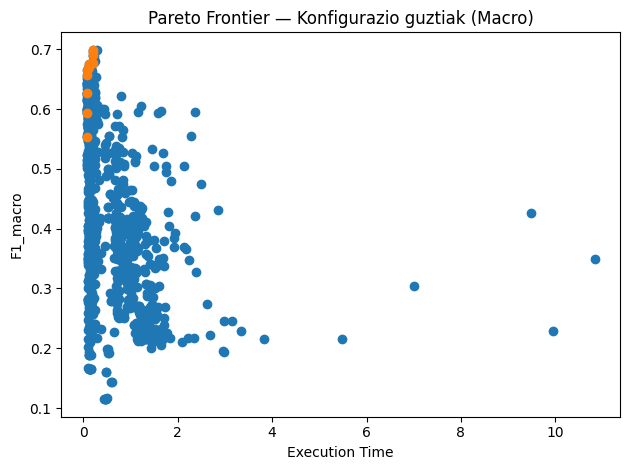

,experiment,model,shot_type,Froga,Prompt,F1_macro,Avg_exec_time
0,v2_SysPromptMotza,salamandra-7B,zero-shot,4,2,0.553658,0.072368
1,v2_SysPromptMotza,salamandra-7B,zero-shot,4,1,0.593835,0.073252
2,v2_SysPromptMotza,salamandra-7B,zero-shot,4,3,0.627090,0.073265
3,v2_SysPromptMotza,salamandra-7B,zero-shot,1,3,0.656209,0.073414
4,v1_SysPromptMotza,salamandra-7B,zero-shot,1,3,0.665773,0.076417
5,v2_SysPromptLuzea,salamandra-7B,few-shot-2,1,1,0.667584,0.103908
6,v1_SysPromptBerria1,salamandra-7B,few-shot-1,1,3,0.670021,0.116152
7,v2_SysPromptLuzea,salamandra-7B,few-shot-2,4,2,0.672024,0.121283
8,v2_SysPromptLuzea,salamandra-7B,few-shot-2,4,3,0.675809,0.123467
9,v2_SysPromptBerria1,latxa3.1-8B,few-shot-1,1,1,0.677399,0.196898


In [83]:
pareto_macro = pareto_all_points(
    df_opt,
    time_col="Avg_exec_time",
    quality_col="F1_macro"
)

plt.figure()
plt.scatter(df_opt["Avg_exec_time"], df_opt["F1_macro"])
plt.scatter(pareto_macro["Avg_exec_time"], pareto_macro["F1_macro"])

plt.xlabel("Execution Time")
plt.ylabel("F1_macro")
plt.title("Pareto Frontier — Konfigurazio guztiak (Macro)")
plt.tight_layout()
plt.show()

pareto_macro[[
    "experiment","model","shot_type",
    "Froga","Prompt",
    "F1_macro","Avg_exec_time"
]].sort_values("Avg_exec_time").reset_index(drop=True)

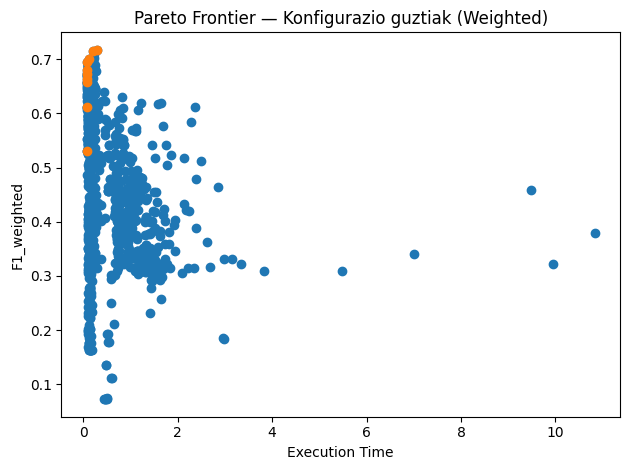

,experiment,model,shot_type,Froga,Prompt,F1_weighted,Avg_exec_time
0,v2_SysPromptMotza,salamandra-7B,zero-shot,4,2,0.529790,0.072368
1,v2_SysPromptMotza,salamandra-7B,zero-shot,4,1,0.611478,0.073252
2,v2_SysPromptMotza,salamandra-7B,zero-shot,4,3,0.656938,0.073265
3,v2_SysPromptMotza,salamandra-7B,zero-shot,1,3,0.663144,0.073414
4,v1_SysPromptMotza,salamandra-7B,zero-shot,1,3,0.672417,0.076417
5,v2_SysPromptMotza,salamandra-7B,few-shot-1,1,3,0.679981,0.077272
6,v1_SysPromptMotza,salamandra-7B,few-shot-1,1,3,0.693978,0.080568
7,v1_SysPromptBerria2,salamandra-7B,few-shot-1,1,3,0.699439,0.126774
8,v2_SysPromptBerria2,latxa3.1-8B,few-shot-1,4,3,0.715835,0.198039
9,v1_SysPromptBerria1,latxa3.1-8B,few-shot-2,4,3,0.717226,0.281686


In [ ]:

pareto_weighted = pareto_all_points(
    df_opt,
    time_col="Avg_exec_time",
    quality_col="F1_weighted"
)

plt.figure()
plt.scatter(df_opt["Avg_exec_time"], df_opt["F1_weighted"])
plt.scatter(pareto_weighted["Avg_exec_time"], pareto_weighted["F1_weighted"])

plt.xlabel("Execution Time")
plt.ylabel("F1_weighted")
plt.title("Pareto Frontier — Konfigurazio guztiak (Weighted)")
plt.tight_layout()
plt.show()

pareto_weighted[[
    "experiment","model","shot_type",
    "Froga","Prompt",
    "F1_weighted","Avg_exec_time"
]].sort_values("Avg_exec_time").reset_index(drop=True)

In [101]:
# Gehien agertzen den esperimentua (macro)
pareto_macro["experiment"].value_counts()

experiment
v2_SysPromptMotza      4
v2_SysPromptLuzea      3
v2_SysPromptBerria2    2
v1_SysPromptBerria1    2
v1_SysPromptMotza      1
v2_SysPromptBerria1    1
Name: count, dtype: int64

In [ ]:
# Gehien agertzen den esperimentua (weighted)
pareto_weighted["experiment"].value_counts()

experiment
v2_SysPromptMotza      5
v1_SysPromptMotza      2
v1_SysPromptBerria2    1
v2_SysPromptBerria2    1
v1_SysPromptBerria1    1
Name: count, dtype: int64

# OUTLIERRAK

In [90]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

In [ ]:
# Denbora
lower_t, upper_t = detect_outliers_iqr(df_opt["Avg_exec_time"])

time_outliers = df_opt[
    (df_opt["Avg_exec_time"] < lower_t) |
    (df_opt["Avg_exec_time"] > upper_t)
]

time_outliers.sort_values("Avg_exec_time", ascending=False)[[
    "experiment","model","shot_type","Froga","Prompt",
    "F1_macro","F1_weighted","Avg_exec_time"
]].head(20)

,experiment,model,shot_type,Froga,Prompt,F1_macro,F1_weighted,Avg_exec_time
128,v1_SysPromptBerria1,llama3.1-70B,zero-shot,1,1,0.348501,0.379821,10.831513
96,v1_SysPromptBerria1,latxa3.1-70B,zero-shot,1,1,0.229296,0.321822,9.953890
1580,v2_SysPromptLuzea,llama3.1-70B,zero-shot,1,1,0.425735,0.458124,9.483308
208,v1_SysPromptBerria2,llama3.1-70B,zero-shot,1,1,0.304648,0.340330,7.011045
192,v1_SysPromptBerria2,latxa3.1-70B,zero-shot,1,1,0.215962,0.308305,5.473613
1308,v2_SysPromptBerria2,latxa3.1-70B,zero-shot,1,1,0.215962,0.308305,3.818491
1068,v2_SysPromptBerria1,latxa3.1-70B,zero-shot,1,1,0.229296,0.321822,3.334703
1548,v2_SysPromptLuzea,latxa3.1-70B,zero-shot,1,1,0.245290,0.331147,3.157597
640,v1_SysPromptMotza,latxa3.1-70B,zero-shot,1,1,0.193112,0.182846,2.983101
400,v1_SysPromptLuzea,latxa3.1-70B,zero-shot,1,1,0.245290,0.331147,2.982278


In [ ]:
# F1_macro
lower_m, upper_m = detect_outliers_iqr(df_opt["F1_macro"])

macro_outliers = df_opt[
    (df_opt["F1_macro"] < lower_m) |
    (df_opt["F1_macro"] > upper_m)
]

macro_outliers.sort_values("F1_macro", ascending=False)[[
    "experiment","model","shot_type","Froga","Prompt",
    "F1_macro","Avg_exec_time"
]].head(20)

,experiment,model,shot_type,Froga,Prompt,F1_macro,Avg_exec_time


In [ ]:
# F1_weighted
lower_w, upper_w = detect_outliers_iqr(df_opt["F1_weighted"])

weighted_outliers = df_opt[
    (df_opt["F1_weighted"] < lower_w) |
    (df_opt["F1_weighted"] > upper_w)
]

weighted_outliers.sort_values("F1_weighted", ascending=False)[[
    "experiment","model","shot_type","Froga","Prompt",
    "F1_weighted","Avg_exec_time"
]].head(20)

,experiment,model,shot_type,Froga,Prompt,F1_weighted,Avg_exec_time


## ZENBAT OUTLIER ETA NON

In [ ]:

time_outliers["model"].value_counts()

model
latxa3.1-70B     12
llama3.1-70B      7
salamandra-7B     1
Name: count, dtype: int64

In [ ]:

time_outliers["shot_type"].value_counts()

shot_type
zero-shot     13
few-shot-2     5
few-shot-1     2
Name: count, dtype: int64

In [ ]:

time_outliers["experiment"].value_counts()

experiment
v1_preSysPrompt        7
v1_SysPromptBerria2    3
v1_SysPromptBerria1    2
v1_SysPromptLuzea      2
v2_SysPromptLuzea      2
v1_SysPromptMotza      1
v2_SysPromptBerria1    1
v2_SysPromptBerria2    1
v2_SysPromptMotza      1
Name: count, dtype: int64